*Importing the needed libraries:*

In [ ]:
import os
import math
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
from tqdm.notebook import tqdm

from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test, multivariate_logrank_test

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.table import Table
import matplotlib.transforms as mtransforms

import scipy.stats
from scipy.stats import norm, zscore, fisher_exact, chi2_contingency, mannwhitneyu

*Setting the parameters for AI-friendly export format of the plots:*

In [ ]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType fonts, keep text editable
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

*Reading the main dataframe with clinical metadata and flow cytometry parameters:*

In [ ]:
# upper day limit for horizoning the clinical follow-up
cutoff = 2000

print('reading the main dataframe:')
# path to the full dataset excel with clinical metadata and flow cytometry parameters for the patients:
full_dataset_clinmetadata_flowcytometrydata_path = ''d35_input_full_copy = d35_input_full[(d35_input_full['OC_d35_PassCrit_FCAnalysis'] == 'Yes') | (d35_input_full['VC_d35_PassCrit_FCAnalysis'] == 'Yes')]
d35_input_full_copy = d35_input_full[(d35_input_full['OC_d35_PassCrit_FCAnalysis'] == 'Yes') | (d35_input_full['VC_d35_PassCrit_FCAnalysis'] == 'Yes')]

PERCENT_FEATURES = [c for c in d35_input_full_copy.columns if ' of ' in c]
myeloid_endings = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid']
myeloid_endings_and_CD45pos = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid', ' of CD45pos']
myeloid_child = set(element.split(' of ')[0] for element in PERCENT_FEATURES if element.endswith(tuple(myeloid_endings)))
myeloid_params_exclude = [element for element in PERCENT_FEATURES if element.startswith(tuple(myeloid_child)) and element.endswith(tuple(myeloid_endings_and_CD45pos))]
PERCENT_FEATURES = list(set(PERCENT_FEATURES) - set(myeloid_params_exclude))

PERCENT_FEATURES_renamer = {}
to_rename = [element for element in PERCENT_FEATURES if 'LowLevel' in element]
for element in to_rename:
    PERCENT_FEATURES_renamer[element] = element.replace('LowLevel ', 'High Resolution ')
d35_input_full_copy = d35_input_full_copy.rename(columns = PERCENT_FEATURES_renamer)
PERCENT_FEATURES = [element.replace('LowLevel ', 'High Resolution ') for element in PERCENT_FEATURES]

RATIO_FEATURES   = [c for c in d35_input_full_copy.columns if '-to-' in c]
OUTCOME_COLS = {
    "RFS": {"time": 'Time_to_Relapse_from_TPL', "event": 'Relapse_Present_1_NotObserved_0'},
    "OS":  {"time": 'Time_to_Death_from_TPL',  "event": 'Death_Present_1_NotObserved_0'},
    "aGVHD": {"time": "Time_to_aGVHD", "event": "aGVHD_grading_by_Katja"},
    "cGVHD": {"time": "Time_to_cGVHD", "event": "cGVHD_grading_by_Katja"},
}

d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = round(d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'], 0)
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'].astype("Int64")
d35_input_full_copy['Cutoff_Plus_SamplingDay'] = cutoff + d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']

# version with horizoning by a sum of cutoff + sampling day & then landmarking (X days post sampling)
d35_input_full_copy[OUTCOME_COLS['RFS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['RFS']['event']])
d35_input_full_copy[OUTCOME_COLS['RFS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['RFS']['time']])
d35_input_full_copy[OUTCOME_COLS['OS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['OS']['event']])
d35_input_full_copy[OUTCOME_COLS['OS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['OS']['time']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']])
d35_input_full_copy['Relapse_Present_1_NotObserved_0'] = d35_input_full_copy['Relapse_Present_1_NotObserved_0'].astype("Int64")
d35_input_full_copy['aGVHD_grading_by_Katja'] = d35_input_full_copy['aGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['cGVHD_grading_by_Katja'] = d35_input_full_copy['cGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['MAX_FOLLOW_UP'] = d35_input_full_copy[['Time_to_aGVHD', 'Time_to_cGVHD',
                                                            'Time_to_Relapse_from_TPL','Time_to_Death_from_TPL']].max(axis = 1)


d35_input_full_copy['Time_to_Death_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_Relapse_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_aGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
# only 65 patients (40 in VC and 25 in OC)
d35_input_full_copy['Time_to_cGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['MAX_FOLLOW_UP'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']

d35_input_full_copy['CMV_Status(R/D)'] = d35_input_full_copy['CMV_Status_Recipient'] + '_' + d35_input_full_copy['CMV_Status_Donor']
d35_input_full_copy['CMV_Status(R/D)'] = d35_input_full_copy['CMV_Status(R/D)'].replace({
    'pos_pos': '+/+',
    'neg_neg': 'Other',
    'pos_neg': 'Other',
    'neg_pos': 'Other',
})

reading the main dataframe:


*Calculating the ICC35 score for the patients:*

In [ ]:
parameters = {
    # 'High Resolution CD8 CCR7- CD45RAmid CD27+ CD57+ GPR56+ of CD45pos': 'GvL_Score',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
    
    # 'High Resolution CD56dim NK CD45RA+ CD57+ CD8+ GPR56+ of Lymphocytes': 'GvHD_Score',
    'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
}

direction = {
    # 'High Resolution CD8 CCR7- CD45RAmid CD27+ CD57+ GPR56+ of CD45pos': 'protective',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
    
    # 'High Resolution CD56dim NK CD45RA+ CD57+ CD8+ GPR56+ of Lymphocytes': 'protective',
    'CD4 CCR7mid CD45RA- of T': 'non-protective',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'non-protective'
}

def sign_intepreter(parameter):
    if direction[parameter] == 'protective':
        return [1,0]
    else:
        return [0,1]

cutoffs = {}
for parameter in list(parameters.keys()):
    cutoffs[parameter] = {
        'OC': np.median(d35_input_full_copy[d35_input_full_copy['Cohort'] == 'OC'][parameter]),
        'VC': np.median(d35_input_full_copy[d35_input_full_copy['Cohort'] == 'VC'][parameter])
    }

for parameter in cutoffs:
    d35_input_full_copy[f'{parameter}_SCORE'] = np.where(d35_input_full_copy['Cohort'] == 'OC',
                                                     np.where(d35_input_full_copy[parameter] > cutoffs[parameter]['OC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1]),
                                                     np.where(d35_input_full_copy[parameter] > cutoffs[parameter]['VC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1])
                                                    )
GvL_params = list({k:v for k,v in parameters.items() if v == 'GvL_Score'}.keys())
GvHD_params = list({k:v for k,v in parameters.items() if v == 'GvHD_Score'}.keys())
d35_input_full_copy['GvL_Score'] = d35_input_full_copy[[f'{element}_SCORE' for element in GvL_params]].sum(axis = 1)
d35_input_full_copy['GvHD_Score'] = d35_input_full_copy[[f'{element}_SCORE' for element in GvHD_params]].sum(axis = 1)
d35_input_full_copy['GvLhi_GvHDlo'] = np.where((d35_input_full_copy['GvL_Score'] == len({k:v for k,v in parameters.items() if v == 'GvL_Score'})) & 
                                         (d35_input_full_copy['GvHD_Score'] == len({k:v for k,v in parameters.items() if v == 'GvHD_Score'})), 1, 0)

*Creating function for correct cumulative indicidence plots:*

In [ ]:
def add_ajf_censors(ax, ajf, color, ms=4, mew=0.8):
    """
    Manually add censor ticks to an AalenJohansenFitter cumulative incidence plot.
    Only true censored observations are marked, not competing events.
    """

    # Times where true censoring occurred
    censored_times = ajf.event_table.index[
        ajf.event_table["censored"] > 0
    ].values.astype(float)

    if len(censored_times) == 0:
        return

    # CIF step function
    cif = ajf.cumulative_density_.iloc[:, 0]

    # Get CIF value at censor times using previous step value
    censor_y = (
        cif
        .reindex(cif.index.union(censored_times))
        .sort_index()
        .ffill()
        .loc[censored_times]
        .values
    )

    ax.plot(
        censored_times,
        censor_y,
        linestyle="None",
        marker="|",
        markersize=ms,
        markeredgewidth=mew,
        color=color
    )

<br></br>
<br></br>
<br></br>
*Figure 2: Plotting the Kaplan-Meier curves for relapse-associated CD8 parameters:*

In [16]:
CD8_parameter_HighRes = 'High Resolution CD8 CCR7- CD45RAmid CD27dim CD57+ GPR56+ of CD45pos'
CD8_parameter_General = 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM'

selected_parameter = CD8_parameter_HighRes
clinical_variable_KM = 'RFS'

In [17]:
d35_input_full_copy_C1 = d35_input_full_copy[d35_input_full_copy['Cohort'] == 'OC']
d35_input_full_copy_C1['Category'] = np.where(d35_input_full_copy_C1[selected_parameter] > np.median(d35_input_full_copy_C1[selected_parameter]),'> median', '≤ median')
d35_input_full_copy_C1['Category_Final'] = np.where(d35_input_full_copy_C1['Category'] == '> median',
                                                    f"> median ({len(d35_input_full_copy_C1[(d35_input_full_copy_C1['Category'] == '> median') & (d35_input_full_copy_C1[OUTCOME_COLS[clinical_variable_KM]['event']] != 0)])}/{len(d35_input_full_copy_C1[d35_input_full_copy_C1['Category'] == '> median'])})",
                                                    f"≤ median ({len(d35_input_full_copy_C1[(d35_input_full_copy_C1['Category'] == '≤ median') & (d35_input_full_copy_C1[OUTCOME_COLS[clinical_variable_KM]['event']] != 0)])}/{len(d35_input_full_copy_C1[d35_input_full_copy_C1['Category'] == '≤ median'])})")
                                                    

d35_input_full_copy_C2 = d35_input_full_copy[d35_input_full_copy['Cohort'] == 'VC']
d35_input_full_copy_C2['Category'] = np.where(d35_input_full_copy_C2[selected_parameter] > np.median(d35_input_full_copy_C2[selected_parameter]), '> median', '≤ median')
d35_input_full_copy_C2['Category_Final'] = np.where(d35_input_full_copy_C2['Category'] == '> median',
                                                    f"> median ({len(d35_input_full_copy_C2[(d35_input_full_copy_C2['Category'] == '> median') & (d35_input_full_copy_C2[OUTCOME_COLS[clinical_variable_KM]['event']] != 0)])}/{len(d35_input_full_copy_C2[d35_input_full_copy_C2['Category'] == '> median'])})",
                                                    f"≤ median ({len(d35_input_full_copy_C2[(d35_input_full_copy_C2['Category'] == '≤ median') & (d35_input_full_copy_C2[OUTCOME_COLS[clinical_variable_KM]['event']] != 0)])}/{len(d35_input_full_copy_C2[d35_input_full_copy_C2['Category'] == '≤ median'])})")

title_renamer = {
    'High Resolution CD8 CCR7- CD45RAmid CD27dim CD57+ GPR56+ of CD45pos': 'HighRes CD8 TEM-adv1\nCD27+ CD57+ GPR56+ of CD45pos',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM-adv1 GPR56+ CD57+ of CD8 TEM'
}
path_renamer = {
    'High Resolution CD8 CCR7- CD45RAmid CD27dim CD57+ GPR56+ of CD45pos': 'CD8TEM_HighRes',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8TEM_General'
}

*Pre-calculated cumulative indicence p-values (using Gray's test, see "./Further analyses/CumulativeIncidence_GraysTest.R")*

In [20]:
CD8_param_split_RFS_cif_values = {
    'OC': {
        'High Resolution CD8 CCR7- CD45RAmid CD27dim CD57+ GPR56+ of CD45pos': 0.08150866,
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 0.05676565,
    },
    'VC': {
        'High Resolution CD8 CCR7- CD45RAmid CD27dim CD57+ GPR56+ of CD45pos': 0.1373475,
        'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 0.1644992,
    },
}

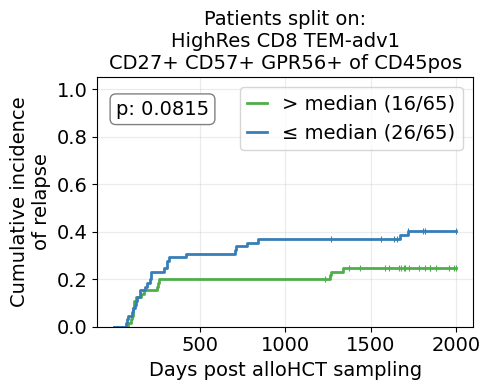

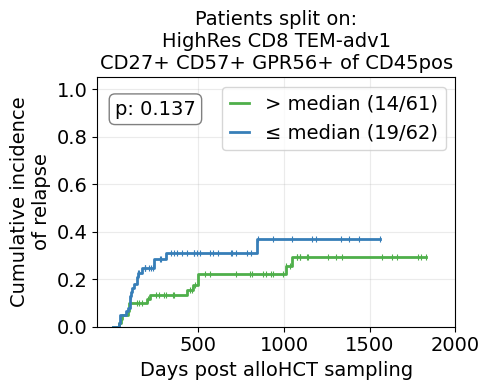

In [ ]:
for cohort in ["OC", "VC"]:

    if clinical_variable_KM == "OS":
        plot_type = "survival"
    elif clinical_variable_KM == "RFS":
        plot_type = "cif_relapse"

    width = 5
    height = 4

    if cohort == "OC":
        df = d35_input_full_copy_C1.copy()
    elif cohort == "VC":
        df = d35_input_full_copy_C2.copy()

    use_custom_pallette = True
    custom_pallette = ["#4eaf4a", "#377eb8"]

    CLUSTER_COL = "Category_Final"

    # specify the output directory for the KM plots:
    base_dir_km_plots = ''
    save_path = (
        f"{base_dir_km_plots}/{path_renamer[selected_parameter]}_{clinical_variable_KM}_{cohort}.pdf"
    )

    fig, ax = plt.subplots(figsize=(width, height))

    # ------------------------------------------------------------
    # Define time/event columns
    # ------------------------------------------------------------

    if clinical_variable_KM == "OS":

        df = df.rename(columns={
            OUTCOME_COLS[clinical_variable_KM]["event"]: "event",
            OUTCOME_COLS[clinical_variable_KM]["time"]: "time"
        })

    elif clinical_variable_KM == "RFS":

        # For relapse CIF:
        # 0 = censored
        # 1 = relapse
        # 2 = death without relapse

        relapse_event_col = "Relapse_Present_1_NotObserved_0"
        relapse_time_col = "Time_to_Relapse_from_TPL"

        death_event_col = "Death_Present_1_NotObserved_0"
        death_time_col = "Time_to_Death_from_TPL"

        # If your times are already landmark-adjusted / censored at 2000 days,
        # use the corresponding adjusted column names here instead.
        df["time"] = df[relapse_time_col]
        df["event"] = 0

        # Relapse is event of interest
        df.loc[df[relapse_event_col] == 1, "event"] = 1

        # Death without relapse is competing event
        df.loc[
            (df[relapse_event_col] == 0) &
            (df[death_event_col] == 1),
            "event"
        ] = 2

        # For death without relapse, time should be time to death, not time to relapse censoring
        df.loc[
            (df[relapse_event_col] == 0) &
            (df[death_event_col] == 1),
            "time"
        ] = df.loc[
            (df[relapse_event_col] == 0) &
            (df[death_event_col] == 1),
            death_time_col
        ]

    # Keep only valid rows
    df = df[[CLUSTER_COL, "time", "event"]].dropna().copy()

    # groups in a nice order
    groups = sorted(
        df[CLUSTER_COL].dropna().unique(),
        key=lambda g: (str(g).startswith(">="), str(g))
    )

    # palette
    if use_custom_pallette is False:
        palette = sns.color_palette("tab10", n_colors=len(groups))
    else:
        palette = sns.color_palette(custom_pallette, n_colors=len(groups))

    color_map = dict(zip(groups, palette))

    # ------------------------------------------------------------
    # Fit + plot
    # ------------------------------------------------------------

    fitters = []

    for g in groups:
        mask = df[CLUSTER_COL] == g

        if plot_type == "survival":

            km = KaplanMeierFitter()
            km.fit(
                durations=df.loc[mask, "time"],
                event_observed=df.loc[mask, "event"],
                label=str(g)
            )

            km.plot_survival_function(
                ax=ax,
                ci_show=False,
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),
                color=color_map[g],
                linewidth=2
            )

            fitters.append(km)

        elif plot_type == "cif_relapse":

            ajf = AalenJohansenFitter()
            ajf.fit(
                durations=df.loc[mask, "time"],
                event_observed=df.loc[mask, "event"],
                event_of_interest=1,
                label=str(g)
            )

            ajf.plot_cumulative_density(
                ax=ax,
                ci_show=False,
                color=color_map[g],
                linewidth=2
            )

            add_ajf_censors(
                ax=ax,
                ajf=ajf,
                color=color_map[g],
                ms=4,
                mew=0.8
            )

            fitters.append(ajf)

    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)

    fontsize_fixed = 14

    # ------------------------------------------------------------
    # P-value
    # ------------------------------------------------------------

    if clinical_variable_KM == "OS":

        results = multivariate_logrank_test(
            event_durations=df["time"],
            groups=df[CLUSTER_COL],
            event_observed=df["event"]
        )

        ax.text(
            0.65, 0.15,
            f"p: {results.p_value:.3g}",
            transform=ax.transAxes,
            fontsize=fontsize_fixed,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=1)
        )

    elif clinical_variable_KM == "RFS":

        # Important:
        # This is NOT Gray's test.
        # Log-rank is not the standard test for competing-risk CIFs.
        # Better either omit p-value here or calculate Gray's test separately in R.
        ax.text(
            0.05, 0.85,
            f"p: {CD8_param_split_RFS_cif_values[cohort][selected_parameter]:.3g}",
            transform=ax.transAxes,
            fontsize=fontsize_fixed,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=1)
        )

    # ------------------------------------------------------------
    # Labels
    # ------------------------------------------------------------

    ax.set_title(
        f"Patients split on:\n{title_renamer[selected_parameter]}",
        fontsize=fontsize_fixed
    )

    if clinical_variable_KM == "RFS":
        ax.set_ylabel("Cumulative incidence\nof relapse", fontsize=fontsize_fixed)
    elif clinical_variable_KM == "OS":
        ax.set_ylabel("Overall survival", fontsize=fontsize_fixed)

    ax.set_xlabel("Days post alloHCT sampling", fontsize=fontsize_fixed)
    ax.set_xticks([500, 1000, 1500, 2000])

    ax.tick_params(axis="y", labelsize=fontsize_fixed)
    ax.tick_params(axis="x", labelsize=fontsize_fixed)

    if clinical_variable_KM == "RFS":
        ax.legend(
            loc="upper right",
            fontsize=fontsize_fixed,
            handlelength=1
        )
    elif clinical_variable_KM == "OS":
        ax.legend(
            loc="lower left",
            fontsize=fontsize_fixed,
            handlelength=1
        )

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", transparent=True)
    plt.show()

<br></br>
*Figure 3: Splitting on CD8 TEM parameters & showing the importance of CD4 for overall survival:*

In [53]:
CD8_parameter = 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM'
CD4TCM_parameter = 'CD4 CCR7mid CD45RA- of T'
CD4TCM_highres_parameter_HLADRneg = 'High Resolution CD4 CCR7mid CD45RA- CD27+ CD29+ of T'
CD4TCM_highres_parameter_HLADRpos = 'High Resolution CD4 CCR7mid CD45RA- CD27+ CD29+ HLA-DR+ of T'

CD4TCM_selected = CD4TCM_parameter
clinical_variable_KM = 'OS'
CD8_subset = 'CD8lo'
# 'CD8hi' / 'CD8lo'
divide_by_second_param = 'CD8first'
# 'upfront' / 'CD8first'

title_renamer = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM',
    'CD4 CCR7mid CD45RA- of T': 'CD4 TCM of T',
    'High Resolution CD4 CCR7mid CD45RA- CD27+ CD29+ of T': 'CD4 TCM CD27+ CD29+ of T',
    'High Resolution CD4 CCR7mid CD45RA- CD27+ CD29+ HLA-DR+ of T': 'CD4 TCM CD27+ CD29+ HLA-DR+ of T',
}

path_renamer = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GeneralCD8TEMadv1++',
    'CD4 CCR7mid CD45RA- of T': 'GeneralCD4TCMofT',
    'High Resolution CD4 CCR7mid CD45RA- CD27+ CD29+ of T': 'HighResHLADRnegCD4TCMofT',
    'High Resolution CD4 CCR7mid CD45RA- CD27+ CD29+ HLA-DR+ of T': 'HighResHLADRposCD4TCMofT',
}

In [54]:
d35_input_full_copy_C1 = d35_input_full_copy[d35_input_full_copy['Cohort'] == 'OC']
d35_input_full_copy_C1['CD8_Category'] = np.where(d35_input_full_copy_C1[CD8_parameter] > np.median(d35_input_full_copy_C1[CD8_parameter]),'CD8hi', 'CD8lo')
if divide_by_second_param == 'CD8first':
    d35_input_full_copy_C1['CD4TCM_Category'] = np.where(d35_input_full_copy_C1['CD8_Category'] == 'CD8hi',
                                                        np.where(d35_input_full_copy_C1[CD4TCM_selected] > np.median(d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == 'CD8hi'][CD4TCM_selected]),'CD4hi', 'CD4lo'),
                                                        np.where(d35_input_full_copy_C1[CD4TCM_selected] > np.median(d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == 'CD8lo'][CD4TCM_selected]),'CD4hi', 'CD4lo'))
elif divide_by_second_param == 'upfront':
    d35_input_full_copy_C1['CD4TCM_Category'] = np.where(d35_input_full_copy_C1[CD4TCM_selected] > np.median(d35_input_full_copy_C1[CD4TCM_selected]),'CD4hi', 'CD4lo')
d35_input_full_copy_C1['Category_Final'] = d35_input_full_copy_C1['CD8_Category'] + '/' + d35_input_full_copy_C1['CD4TCM_Category']
summary = (d35_input_full_copy_C1.groupby("Category_Final").agg(
    total_count=("Category_Final", "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['Category_Final'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict = dict(zip(summary['Category_Final'], summary['Final Labels']))
d35_input_full_copy_C1['Category_Final'] = d35_input_full_copy_C1['Category_Final'].replace(renaming_dict)
d35_input_full_copy_C1 = d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == CD8_subset]

d35_input_full_copy_C2 = d35_input_full_copy[d35_input_full_copy['Cohort'] == 'VC']
d35_input_full_copy_C2['CD8_Category'] = np.where(d35_input_full_copy_C2[CD8_parameter] > np.median(d35_input_full_copy_C2[CD8_parameter]),'CD8hi', 'CD8lo')
if divide_by_second_param == 'CD8first':
    d35_input_full_copy_C2['CD4TCM_Category'] = np.where(d35_input_full_copy_C2['CD8_Category'] == 'CD8hi',
                                                        np.where(d35_input_full_copy_C2[CD4TCM_selected] > np.median(d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == 'CD8hi'][CD4TCM_selected]),'CD4hi', 'CD4lo'),
                                                        np.where(d35_input_full_copy_C2[CD4TCM_selected] > np.median(d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == 'CD8lo'][CD4TCM_selected]),'CD4hi', 'CD4lo'))
elif divide_by_second_param == 'upfront':
    d35_input_full_copy_C2['CD4TCM_Category'] = np.where(d35_input_full_copy_C2[CD4TCM_selected] > np.median(d35_input_full_copy_C2[CD4TCM_selected]),'CD4hi', 'CD4lo')
d35_input_full_copy_C2['Category_Final'] = d35_input_full_copy_C2['CD8_Category'] + '/' + d35_input_full_copy_C2['CD4TCM_Category']
summary = (d35_input_full_copy_C2.groupby("Category_Final").agg(
    total_count=("Category_Final", "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['Category_Final'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict = dict(zip(summary['Category_Final'], summary['Final Labels']))
d35_input_full_copy_C2['Category_Final'] = d35_input_full_copy_C2['Category_Final'].replace(renaming_dict)
d35_input_full_copy_C2 = d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == CD8_subset]


CD8lo_CD4hi_label_c1 = [element for element in d35_input_full_copy_C1['Category_Final'].unique() if 'CD8lo/CD4hi' in element]
CD8hi_CD4hi_label_c1 = [element for element in d35_input_full_copy_C1['Category_Final'].unique() if 'CD8hi/CD4hi' in element]
CD8lo_CD4lo_label_c1 = [element for element in d35_input_full_copy_C1['Category_Final'].unique() if 'CD8lo/CD4lo' in element]
CD8hi_CD4lo_label_c1 = [element for element in d35_input_full_copy_C1['Category_Final'].unique() if 'CD8hi/CD4lo' in element]

CD8lo_CD4hi_label_c2 = [element for element in d35_input_full_copy_C2['Category_Final'].unique() if 'CD8lo/CD4hi' in element]
CD8hi_CD4hi_label_c2 = [element for element in d35_input_full_copy_C2['Category_Final'].unique() if 'CD8hi/CD4hi' in element]
CD8lo_CD4lo_label_c2 = [element for element in d35_input_full_copy_C2['Category_Final'].unique() if 'CD8lo/CD4lo' in element]
CD8hi_CD4lo_label_c2 = [element for element in d35_input_full_copy_C2['Category_Final'].unique() if 'CD8hi/CD4lo' in element]

if CD8_subset == 'CD8lo':
    replacement_dict_c1 = {
        CD8lo_CD4hi_label_c1[0]: '> median',
        CD8lo_CD4lo_label_c1[0]: '≤ median',
    }
    replacement_dict_c2 = {
        CD8lo_CD4hi_label_c2[0]: '> median',
        CD8lo_CD4lo_label_c2[0]: '≤ median',
    }
else:
    replacement_dict_c1 = {
        CD8hi_CD4hi_label_c1[0]: '> median',
        CD8hi_CD4lo_label_c1[0]: '≤ median',
    }
    replacement_dict_c2 = {
        CD8hi_CD4hi_label_c2[0]: '> median',
        CD8hi_CD4lo_label_c2[0]: '≤ median',
    }

d35_input_full_copy_C1['Category_Final'] = d35_input_full_copy_C1['Category_Final'].replace(replacement_dict_c1)
d35_input_full_copy_C2['Category_Final'] = d35_input_full_copy_C2['Category_Final'].replace(replacement_dict_c2)

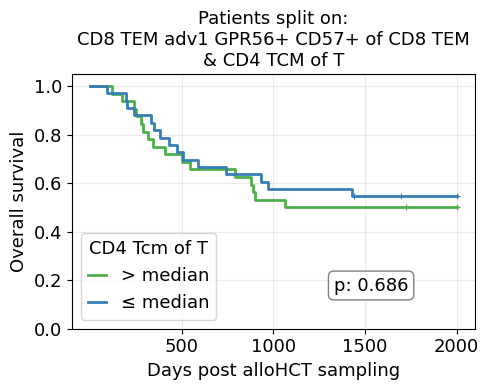

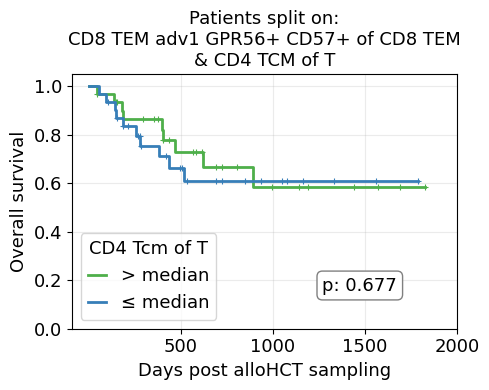

In [ ]:
for cohort in ['OC', 'VC']:
    if clinical_variable_KM == 'OS':
        plot_type = 'survival'
    elif clinical_variable_KM == 'RFS':
        plot_type = 'cumulative'
    # 'survival' / 'cumulative'
    width = 5
    height = 4
    # cohort = 'OC'

    if cohort == 'OC':
        df = d35_input_full_copy_C1.copy()
    elif cohort == 'VC':
        df = d35_input_full_copy_C2.copy()

    use_custom_pallette = True
    # custom_pallette = ['#b30059', '#9ec1e6', '#32CD32','#FFA500', '#FFD700', '#FFB8FF']
    # custom_pallette = ["#E06666", "#6FA8DC"]
    custom_pallette = ["#4eaf4a", "#377eb8"]

    CLUSTER_COL = 'Category_Final'
    if divide_by_second_param == 'upfront':
        # specify the output directory for the KM plots:
        base_dir_km_plots = ''
    elif divide_by_second_param == 'CD8first':
        base_dir_km_plots = ''
    save_path = f'{base_dir_km_plots}{path_renamer[CD8_parameter]}_{CD8_subset}_{path_renamer[CD4TCM_selected]}_{cohort}_OS.pdf'

    fig, ax = plt.subplots(figsize = (width, height)) 

    df = df.rename(columns={
        OUTCOME_COLS[clinical_variable_KM]["event"]: "event",
        OUTCOME_COLS[clinical_variable_KM]["time"]: "time"
    })

    # groups in a nice order (put "< than median" first if present)
    groups = sorted(df[CLUSTER_COL].dropna().unique(),
                    key=lambda g: (str(g).startswith(">="), str(g)))

    # palette
    if use_custom_pallette is False:
        palette = sns.color_palette("tab10", n_colors=len(groups))
    else:
        palette = sns.color_palette(custom_pallette, n_colors=len(groups))
    color_map = dict(zip(groups, palette))

    # fit + plot; collect km objects for the risk table
    kmfs = []
    for g in groups:
        mask = (df[CLUSTER_COL] == g)
        km = KaplanMeierFitter()
        km.fit(df.loc[mask, "time"],
                event_observed=df.loc[mask, "event"],
            #    label=f"{g}\n(# pat: {int(mask.sum())})")
            label=f"{g}")
        if plot_type == 'survival':
            km.plot_survival_function(
                ax=ax,
                ci_show=False,                 # no shaded CI band (like your target)
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),  # small censor ticks
                color=color_map[g],
                linewidth=2
            )
        elif plot_type == 'cumulative':
            km.plot_cumulative_density(
                ax=ax,
                ci_show=False,
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),
                color=color_map[g],
                linewidth=2
            )
        kmfs.append(km)
    ax.set_ylim(0, 1.05)


    ax.grid(alpha=0.25)
    fontsize_fixed = 13
    # elif len(groups) > 2:
    # print('using the multivariate logrank test')
    results = multivariate_logrank_test(
        event_durations=df["time"],
        groups=df[CLUSTER_COL],
        event_observed=df["event"]
    )
    if clinical_variable_KM == 'OS':
        ax.text(0.65, 0.15, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))
    elif clinical_variable_KM == 'RFS':
        ax.text(0.05, 0.85, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))

    ax.set_title(f'Patients split on:\n{title_renamer[CD8_parameter]}\n& {title_renamer[CD4TCM_selected]}', fontsize = fontsize_fixed)
    
    if clinical_variable_KM == 'RFS':
        ax.set_ylabel('Cumulative incidence\nof relapse', fontsize = fontsize_fixed)
    elif clinical_variable_KM == 'OS':
        ax.set_ylabel('Overall survival', fontsize = fontsize_fixed)
    ax.set_xlabel('Days post alloHCT sampling', fontsize = fontsize_fixed)
    ax.set_xticks([500, 1000, 1500, 2000])

    ax.tick_params(axis="y", labelsize = fontsize_fixed)
    ax.tick_params(axis="x", labelsize = fontsize_fixed)

    ax.legend(fontsize = fontsize_fixed,
              handlelength=0.7)
    if clinical_variable_KM == 'RFS':
        ax.legend(loc='upper right',
                  fontsize = fontsize_fixed,
                  handlelength=1, title = 'CD4 Tcm of T', title_fontsize = fontsize_fixed)
    elif clinical_variable_KM == 'OS':
        ax.legend(loc='lower left',
                  fontsize = fontsize_fixed,
                  handlelength=1, title = 'CD4 Tcm of T', title_fontsize = fontsize_fixed)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches = 'tight', transparent=True)
    plt.show()

<br></br>
*Figure 3: Splitting on CD8 TEM parameters & showing the importance of CD56dim NK (broad) for overall survival:*

In [27]:
CD8_parameter = 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM'
CD56dimNK_parameter = 'CD56dim NK CD57+ GPR56+ of Lymphocytes'

clinical_variable_KM = 'OS'
CD8_subset = 'CD8lo'
# 'CD8hi' / 'CD8lo'
divide_by_second_param = 'CD8first'
# 'upfront' / 'CD8first'

title_renamer = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM',
    'CD56dim NK CD57+ GPR56+ of Lymphocytes': 'CD56dim NK CD57+ GPR56+ of Lymphocytes',
}

path_renamer = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GeneralCD8TEMadv1++',
    'CD56dim NK CD57+ GPR56+ of Lymphocytes': 'CD56dimNK_CD57+GPR56+_ofLymph',
}

In [28]:
d35_input_full_copy_C1 = d35_input_full_copy[d35_input_full_copy['Cohort'] == 'OC']
d35_input_full_copy_C1['CD8_Category'] = np.where(d35_input_full_copy_C1[CD8_parameter] > np.median(d35_input_full_copy_C1[CD8_parameter]),'CD8hi', 'CD8lo')
if divide_by_second_param == 'CD8first':
    d35_input_full_copy_C1['NK_Category'] = np.where(d35_input_full_copy_C1['CD8_Category'] == 'CD8hi',
                                                         np.where(d35_input_full_copy_C1[CD56dimNK_parameter] > np.median(d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == 'CD8hi'][CD56dimNK_parameter]),'NKhi', 'NKlo'),
                                                         np.where(d35_input_full_copy_C1[CD56dimNK_parameter] > np.median(d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == 'CD8lo'][CD56dimNK_parameter]),'NKhi', 'NKlo'))
elif divide_by_second_param == 'upfront':
    d35_input_full_copy_C1['NK_Category'] = np.where(d35_input_full_copy_C1[CD56dimNK_parameter] > np.median(d35_input_full_copy_C1[CD56dimNK_parameter]),'NKhi', 'NKlo')
d35_input_full_copy_C1['Category_Final'] = d35_input_full_copy_C1['CD8_Category'] + '/' + d35_input_full_copy_C1['NK_Category']
summary = (d35_input_full_copy_C1.groupby("Category_Final").agg(
    total_count=("Category_Final", "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['Category_Final'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict = dict(zip(summary['Category_Final'], summary['Final Labels']))
d35_input_full_copy_C1['Category_Final'] = d35_input_full_copy_C1['Category_Final'].replace(renaming_dict)
d35_input_full_copy_C1 = d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == CD8_subset]

d35_input_full_copy_C2 = d35_input_full_copy[d35_input_full_copy['Cohort'] == 'VC']
d35_input_full_copy_C2['CD8_Category'] = np.where(d35_input_full_copy_C2[CD8_parameter] > np.median(d35_input_full_copy_C2[CD8_parameter]),'CD8hi', 'CD8lo')
if divide_by_second_param == 'CD8first':
    d35_input_full_copy_C2['NK_Category'] = np.where(d35_input_full_copy_C2['CD8_Category'] == 'CD8hi',
                                                        np.where(d35_input_full_copy_C2[CD56dimNK_parameter] > np.median(d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == 'CD8hi'][CD56dimNK_parameter]),'NKhi', 'NKlo'),
                                                        np.where(d35_input_full_copy_C2[CD56dimNK_parameter] > np.median(d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == 'CD8lo'][CD56dimNK_parameter]),'NKhi', 'NKlo'))
elif divide_by_second_param == 'upfront':
    d35_input_full_copy_C2['NK_Category'] = np.where(d35_input_full_copy_C2[CD56dimNK_parameter] > np.median(d35_input_full_copy_C2[CD56dimNK_parameter]),'NKhi', 'NKlo')
d35_input_full_copy_C2['Category_Final'] = d35_input_full_copy_C2['CD8_Category'] + '/' + d35_input_full_copy_C2['NK_Category']
summary = (d35_input_full_copy_C2.groupby("Category_Final").agg(
    total_count=("Category_Final", "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['Category_Final'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict = dict(zip(summary['Category_Final'], summary['Final Labels']))
d35_input_full_copy_C2['Category_Final'] = d35_input_full_copy_C2['Category_Final'].replace(renaming_dict)
d35_input_full_copy_C2 = d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == CD8_subset]

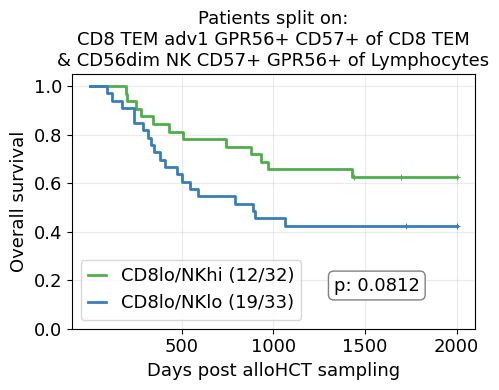

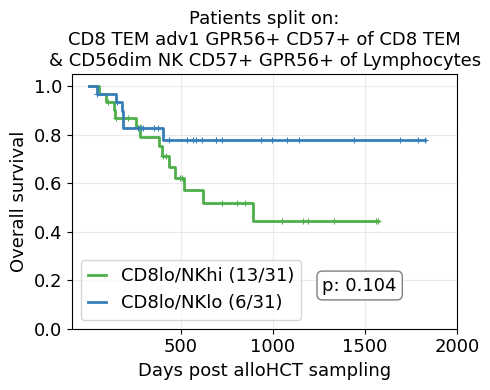

In [ ]:
for cohort in ['OC', 'VC']:
    if clinical_variable_KM == 'OS':
        plot_type = 'survival'
    elif clinical_variable_KM == 'RFS':
        plot_type = 'cumulative'
    # 'survival' / 'cumulative'
    width = 5
    height = 4
    # cohort = 'OC'

    if cohort == 'OC':
        df = d35_input_full_copy_C1.copy()
    elif cohort == 'VC':
        df = d35_input_full_copy_C2.copy()

    use_custom_pallette = True
    # custom_pallette = ['#b30059', '#9ec1e6', '#32CD32','#FFA500', '#FFD700', '#FFB8FF']
    # custom_pallette = ["#E06666", "#6FA8DC"]
    custom_pallette = ["#4eaf4a", "#377eb8"]

    CLUSTER_COL = 'Category_Final'
    if divide_by_second_param == 'upfront':
        # specify the output directory for KM plots:
        base_dir_km_plots = ''
    elif divide_by_second_param == 'CD8first':
        # specify the output directory for KM plots:
        base_dir_km_plots = ''
    save_path = f'{base_dir_km_plots}{path_renamer[CD8_parameter]}_{CD8_subset}_{path_renamer[CD56dimNK_parameter]}_{cohort}_OS.pdf'

    fig, ax = plt.subplots(figsize = (width, height)) 

    df = df.rename(columns={
        OUTCOME_COLS[clinical_variable_KM]["event"]: "event",
        OUTCOME_COLS[clinical_variable_KM]["time"]: "time"
    })

    # groups in a nice order (put "< than median" first if present)
    groups = sorted(df[CLUSTER_COL].dropna().unique(),
                    key=lambda g: (str(g).startswith(">="), str(g)))

    # palette
    if use_custom_pallette is False:
        palette = sns.color_palette("tab10", n_colors=len(groups))
    else:
        palette = sns.color_palette(custom_pallette, n_colors=len(groups))
    color_map = dict(zip(groups, palette))

    # fit + plot; collect km objects for the risk table
    kmfs = []
    for g in groups:
        mask = (df[CLUSTER_COL] == g)
        km = KaplanMeierFitter()
        km.fit(df.loc[mask, "time"],
                event_observed=df.loc[mask, "event"],
            #    label=f"{g}\n(# pat: {int(mask.sum())})")
            label=f"{g}")
        if plot_type == 'survival':
            km.plot_survival_function(
                ax=ax,
                ci_show=False,                 # no shaded CI band (like your target)
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),  # small censor ticks
                color=color_map[g],
                linewidth=2
            )
        elif plot_type == 'cumulative':
            km.plot_cumulative_density(
                ax=ax,
                ci_show=False,
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),
                color=color_map[g],
                linewidth=2
            )
        kmfs.append(km)
    ax.set_ylim(0, 1.05)


    ax.grid(alpha=0.25)
    fontsize_fixed = 13
    # elif len(groups) > 2:
    # print('using the multivariate logrank test')
    results = multivariate_logrank_test(
        event_durations=df["time"],
        groups=df[CLUSTER_COL],
        event_observed=df["event"]
    )
    if clinical_variable_KM == 'OS':
        ax.text(0.65, 0.15, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))
    elif clinical_variable_KM == 'RFS':
        ax.text(0.05, 0.85, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))

    ax.set_title(f'Patients split on:\n{title_renamer[CD8_parameter]}\n& {title_renamer[CD56dimNK_parameter]}', fontsize = fontsize_fixed)
    
    if clinical_variable_KM == 'RFS':
        ax.set_ylabel('Cumulative incidence\nof relapse', fontsize = fontsize_fixed)
    elif clinical_variable_KM == 'OS':
        ax.set_ylabel('Overall survival', fontsize = fontsize_fixed)
    ax.set_xlabel('Days post alloHCT sampling', fontsize = fontsize_fixed)
    ax.set_xticks([500, 1000, 1500, 2000])

    ax.tick_params(axis="y", labelsize = fontsize_fixed)
    ax.tick_params(axis="x", labelsize = fontsize_fixed)

    ax.legend(fontsize = fontsize_fixed,
              handlelength=0.7)
    if clinical_variable_KM == 'RFS':
        ax.legend(loc='upper right',
                  fontsize = fontsize_fixed,
                  handlelength=1)
    elif clinical_variable_KM == 'OS':
        ax.legend(loc='lower left',
                  fontsize = fontsize_fixed,
                  handlelength=1)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches = 'tight', transparent=True)
    plt.show()

<br></br>
*Figure 3: Splitting on CD8 TEM parameters & showing the importance of CD56dim NK (HighRes) for overall survival:*

In [104]:
CD8_parameter = 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM'
CD56dimNK_parameter = 'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes'

clinical_variable_KM = 'OS'
CD8_subset = 'CD8lo'
# 'CD8hi' / 'CD8lo'
divide_by_second_param = 'upfront'
# 'upfront' / 'CD8first'

title_renamer = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM',
    'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'HighRes CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes',
}

path_renamer = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GeneralCD8TEMadv1++',
    'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'HighRes_CD56dimNK_CD45RA+CD57+GPR56+_ofLymph',
}

In [105]:
d35_input_full_copy_C1 = d35_input_full_copy[d35_input_full_copy['Cohort'] == 'OC']
d35_input_full_copy_C1['CD8_Category'] = np.where(d35_input_full_copy_C1[CD8_parameter] > np.median(d35_input_full_copy_C1[CD8_parameter]),'CD8hi', 'CD8lo')
if divide_by_second_param == 'CD8first':
    d35_input_full_copy_C1['NK_Category'] = np.where(d35_input_full_copy_C1['CD8_Category'] == 'CD8hi',
                                                         np.where(d35_input_full_copy_C1[CD56dimNK_parameter] > np.median(d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == 'CD8hi'][CD56dimNK_parameter]),'NKhi', 'NKlo'),
                                                         np.where(d35_input_full_copy_C1[CD56dimNK_parameter] > np.median(d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == 'CD8lo'][CD56dimNK_parameter]),'NKhi', 'NKlo'))
elif divide_by_second_param == 'upfront':
    d35_input_full_copy_C1['NK_Category'] = np.where(d35_input_full_copy_C1[CD56dimNK_parameter] > np.median(d35_input_full_copy_C1[CD56dimNK_parameter]),'NKhi', 'NKlo')
d35_input_full_copy_C1['Category_Final'] = d35_input_full_copy_C1['CD8_Category'] + '/' + d35_input_full_copy_C1['NK_Category']
summary = (d35_input_full_copy_C1.groupby("Category_Final").agg(
    total_count=("Category_Final", "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['Category_Final'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict = dict(zip(summary['Category_Final'], summary['Final Labels']))
d35_input_full_copy_C1['Category_Final'] = d35_input_full_copy_C1['Category_Final'].replace(renaming_dict)
d35_input_full_copy_C1 = d35_input_full_copy_C1[d35_input_full_copy_C1['CD8_Category'] == CD8_subset]

d35_input_full_copy_C2 = d35_input_full_copy[d35_input_full_copy['Cohort'] == 'VC']
d35_input_full_copy_C2['CD8_Category'] = np.where(d35_input_full_copy_C2[CD8_parameter] > np.median(d35_input_full_copy_C2[CD8_parameter]),'CD8hi', 'CD8lo')
if divide_by_second_param == 'CD8first':
    d35_input_full_copy_C2['NK_Category'] = np.where(d35_input_full_copy_C2['CD8_Category'] == 'CD8hi',
                                                        np.where(d35_input_full_copy_C2[CD56dimNK_parameter] > np.median(d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == 'CD8hi'][CD56dimNK_parameter]),'NKhi', 'NKlo'),
                                                        np.where(d35_input_full_copy_C2[CD56dimNK_parameter] > np.median(d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == 'CD8lo'][CD56dimNK_parameter]),'NKhi', 'NKlo'))
elif divide_by_second_param == 'upfront':
    d35_input_full_copy_C2['NK_Category'] = np.where(d35_input_full_copy_C2[CD56dimNK_parameter] > np.median(d35_input_full_copy_C2[CD56dimNK_parameter]),'NKhi', 'NKlo')
d35_input_full_copy_C2['Category_Final'] = d35_input_full_copy_C2['CD8_Category'] + '/' + d35_input_full_copy_C2['NK_Category']
summary = (d35_input_full_copy_C2.groupby("Category_Final").agg(
    total_count=("Category_Final", "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['Category_Final'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict = dict(zip(summary['Category_Final'], summary['Final Labels']))
d35_input_full_copy_C2['Category_Final'] = d35_input_full_copy_C2['Category_Final'].replace(renaming_dict)
d35_input_full_copy_C2 = d35_input_full_copy_C2[d35_input_full_copy_C2['CD8_Category'] == CD8_subset]

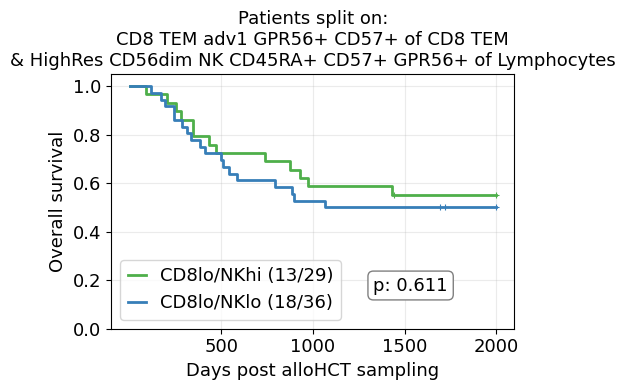

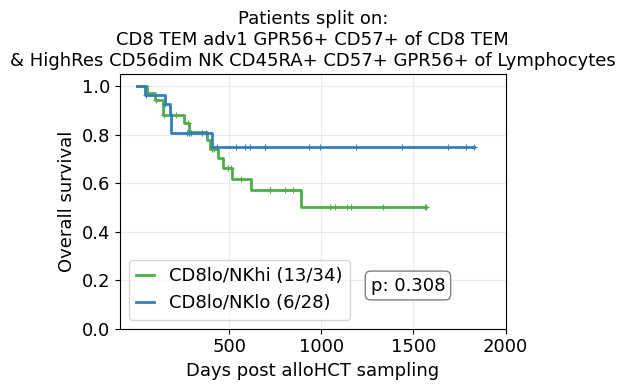

In [ ]:
for cohort in ['OC', 'VC']:
    if clinical_variable_KM == 'OS':
        plot_type = 'survival'
    elif clinical_variable_KM == 'RFS':
        plot_type = 'cumulative'
    # 'survival' / 'cumulative'
    width = 5
    height = 4
    # cohort = 'OC'

    if cohort == 'OC':
        df = d35_input_full_copy_C1.copy()
    elif cohort == 'VC':
        df = d35_input_full_copy_C2.copy()

    use_custom_pallette = True
    # custom_pallette = ['#b30059', '#9ec1e6', '#32CD32','#FFA500', '#FFD700', '#FFB8FF']
    # custom_pallette = ["#E06666", "#6FA8DC"]
    custom_pallette = ["#4eaf4a", "#377eb8"]

    CLUSTER_COL = 'Category_Final'
    if divide_by_second_param == 'upfront':
        # specify the output directory for KM plots:
        base_dir_km_plots = ''
    elif divide_by_second_param == 'CD8first':
        # specify the output directory for KM plots:
        base_dir_km_plots = ''
    save_path = f'{base_dir_km_plots}{path_renamer[CD8_parameter]}_{CD8_subset}_{path_renamer[CD56dimNK_parameter]}_{cohort}_OS.pdf'

    fig, ax = plt.subplots(figsize = (width, height)) 

    df = df.rename(columns={
        OUTCOME_COLS[clinical_variable_KM]["event"]: "event",
        OUTCOME_COLS[clinical_variable_KM]["time"]: "time"
    })

    # groups in a nice order (put "< than median" first if present)
    groups = sorted(df[CLUSTER_COL].dropna().unique(),
                    key=lambda g: (str(g).startswith(">="), str(g)))

    # palette
    if use_custom_pallette is False:
        palette = sns.color_palette("tab10", n_colors=len(groups))
    else:
        palette = sns.color_palette(custom_pallette, n_colors=len(groups))
    color_map = dict(zip(groups, palette))

    # fit + plot; collect km objects for the risk table
    kmfs = []
    for g in groups:
        mask = (df[CLUSTER_COL] == g)
        km = KaplanMeierFitter()
        km.fit(df.loc[mask, "time"],
                event_observed=df.loc[mask, "event"],
            #    label=f"{g}\n(# pat: {int(mask.sum())})")
            label=f"{g}")
        if plot_type == 'survival':
            km.plot_survival_function(
                ax=ax,
                ci_show=False,                 # no shaded CI band (like your target)
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),  # small censor ticks
                color=color_map[g],
                linewidth=2
            )
        elif plot_type == 'cumulative':
            km.plot_cumulative_density(
                ax=ax,
                ci_show=False,
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),
                color=color_map[g],
                linewidth=2
            )
        kmfs.append(km)
    ax.set_ylim(0, 1.05)


    ax.grid(alpha=0.25)
    fontsize_fixed = 13
    # elif len(groups) > 2:
    # print('using the multivariate logrank test')
    results = multivariate_logrank_test(
        event_durations=df["time"],
        groups=df[CLUSTER_COL],
        event_observed=df["event"]
    )
    if clinical_variable_KM == 'OS':
        ax.text(0.65, 0.15, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))
    elif clinical_variable_KM == 'RFS':
        ax.text(0.05, 0.85, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))

    ax.set_title(f'Patients split on:\n{title_renamer[CD8_parameter]}\n& {title_renamer[CD56dimNK_parameter]}', fontsize = fontsize_fixed)
    
    if clinical_variable_KM == 'RFS':
        ax.set_ylabel('Cumulative incidence\nof relapse', fontsize = fontsize_fixed)
    elif clinical_variable_KM == 'OS':
        ax.set_ylabel('Overall survival', fontsize = fontsize_fixed)
    ax.set_xlabel('Days post alloHCT sampling', fontsize = fontsize_fixed)
    ax.set_xticks([500, 1000, 1500, 2000])

    ax.tick_params(axis="y", labelsize = fontsize_fixed)
    ax.tick_params(axis="x", labelsize = fontsize_fixed)

    ax.legend(fontsize = fontsize_fixed,
              handlelength=0.7)
    if clinical_variable_KM == 'RFS':
        ax.legend(loc='upper right',
                  fontsize = fontsize_fixed,
                  handlelength=1)
    elif clinical_variable_KM == 'OS':
        ax.legend(loc='lower left',
                  fontsize = fontsize_fixed,
                  handlelength=1)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches = 'tight', transparent=True)
    plt.show()

<br></br>
*Figures 5: Splitting by CMV status first & by 1) GvL score, 2) GvHD score, 3) full score*

In [ ]:
selected_clin_var_col = 'CMV_Status_Recipient'
# 'CMV_Status_Recipient' / 'CMV_Status(R/D)'
selected_level =  'pos'
# 'CMV_Status_Recipient' > 'pos' / 'neg'
# 'CMV_Status(R/D)' > '+/+' / 'Other'
CMV_subset = d35_input_full_copy[d35_input_full_copy[selected_clin_var_col].isin([selected_level])]

selected_score_col = 'GvL_Score'
# 'GvL_Score'
# 'GvHD_Score'
# 'GvLhi_GvHDlo'
# 'CD4 CCR7mid CD45RA- of T_SCORE'
'CD8 TEM-adv1 CCR7mid CD45RA- of T_SCORE'

clinical_variable_KM = 'OS'

scores_to_merge = None
if selected_score_col == 'GvL_Score':
    label_for_bad = 'CD8 TEM +/+\n≤ median'
    label_for_good = 'CD8 TEM +/+\n> median'
    CMV_subset['SplitVar'] = CMV_subset[selected_score_col].replace({0:label_for_bad, 1:label_for_good})
elif selected_score_col == 'GvHD_Score':
    # scores_to_merge = [1,2]
    scores_to_merge = [2]
    label_for_bad = f'GvHDhi ({"/".join(str(element) for element in [a for a in [0,1,2] if a not in scores_to_merge])})'
    label_for_good = f'GvHDlo ({"/".join(str(element) for element in scores_to_merge)})'
    CMV_subset['SplitVar'] = np.where(CMV_subset[selected_score_col].isin(scores_to_merge), label_for_bad, label_for_good)
elif selected_score_col == 'GvLhi_GvHDlo':
    label_for_bad = 'Other'
    label_for_good = 'GoodComp'
    CMV_subset['SplitVar'] = CMV_subset[selected_score_col].replace({0:label_for_bad, 1:label_for_good})
elif selected_score_col == 'CD4 CCR7mid CD45RA- of T_SCORE':
    label_for_bad = 'CD4TCM > median\n'
    label_for_good = 'CD4TCM ≤ median\n'
    CMV_subset['SplitVar'] = CMV_subset[selected_score_col].replace({0:label_for_bad,1:label_for_good})



path_renamer = {
    'GvL_Score': 'GvLScore_CD8TEM++',
    'GvHD_Score': f'GvHDScore_CD4TCMNV(lo={"&".join(str(element) for element in scores_to_merge)})' if scores_to_merge is not None  else '',
    'GvLhi_GvHDlo': 'TotalScore_CD8TEM_CD4TCM_CD4TCMNVratio',
    'CD4 CCR7mid CD45RA- of T_SCORE': 'CD4TCMofT',

    'CMV_Status(R/D)': f'CMVRecDon({selected_level.replace("/","&")})',
    'CMV_Status_Recipient': f'CMVRec({selected_level})',
}

title_renamer = {
    'GvL_Score': 'CD8 TEM-adv1 GPR56+ CD57+ of CD8 TEM',
    'GvHD_Score': f'CD4 TCM and/or CD4TCM+NV-to-rest (lo={"&".join(str(element) for element in scores_to_merge)})' if scores_to_merge is not None  else '',
    'GvLhi_GvHDlo': 'CD8 TEM+/+ & CD4 TCM & CD4TCM+NV ratio',
    'CD4 CCR7mid CD45RA- of T_SCORE': 'CD4 TCM of T',

    'CMV_Status(R/D)': f'CMV Status R/D ({selected_level})',
    'CMV_Status_Recipient': f'CMV Status R ({selected_level})',
}





# full labels with events / total num
d35_input_full_copy_C1 = CMV_subset[CMV_subset['Cohort'] == 'OC']
summary = (d35_input_full_copy_C1.groupby('SplitVar').agg(
    total_count=('SplitVar', "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['SplitVar'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict_OC = dict(zip(summary['SplitVar'], summary['Final Labels']))
d35_input_full_copy_C1['SplitVar'] = d35_input_full_copy_C1['SplitVar'].replace(renaming_dict_OC)

d35_input_full_copy_C2 = CMV_subset[CMV_subset['Cohort'] == 'VC']
summary = (d35_input_full_copy_C2.groupby('SplitVar').agg(
    total_count=('SplitVar', "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['SplitVar'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict_VC = dict(zip(summary['SplitVar'], summary['Final Labels']))
d35_input_full_copy_C2['SplitVar'] = d35_input_full_copy_C2['SplitVar'].replace(renaming_dict_VC)

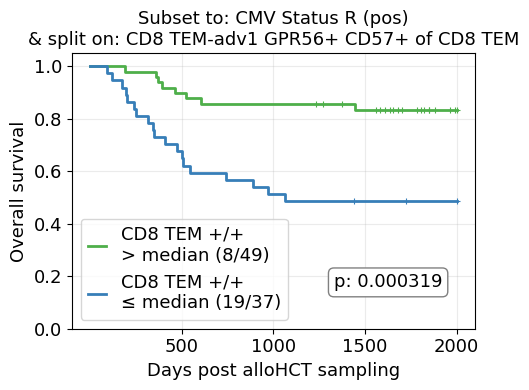

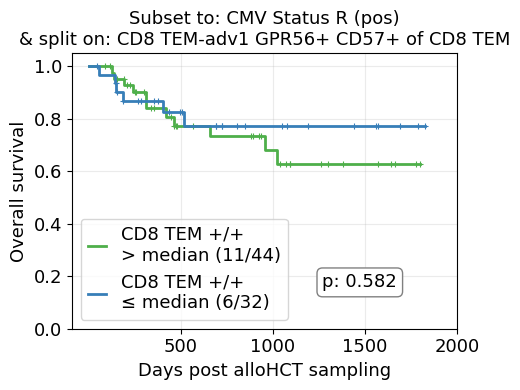

In [ ]:
for cohort in ['OC', 'VC']:
    if clinical_variable_KM == 'OS':
        plot_type = 'survival'
    elif clinical_variable_KM == 'RFS':
        plot_type = 'cumulative'
    # 'survival' / 'cumulative'
    width = 5
    height = 4
    # cohort = 'OC'

    if cohort == 'OC':
        df = d35_input_full_copy_C1.copy()
    elif cohort == 'VC':
        df = d35_input_full_copy_C2.copy()

    use_custom_pallette = True
    # custom_pallette = ['#b30059', '#9ec1e6', '#32CD32','#FFA500', '#FFD700', '#FFB8FF']
    # custom_pallette = ["#E06666", "#6FA8DC"]
    custom_pallette = ["#4eaf4a", "#377eb8"]
    if cohort == 'OC':
        dict_main = renaming_dict_OC
    else:
        dict_main = renaming_dict_VC
    label_for_good_KM_test = dict_main[label_for_good]
    label_for_bad_KM_test = dict_main[label_for_bad]  
    groups = [label_for_good_KM_test, label_for_bad_KM_test]
    color_map = dict(zip(groups, ["#4eaf4a", "#377eb8"]))

    CLUSTER_COL = 'SplitVar'
    # specify the output directory for KM plots:
    base_dir_km_plots = ''
    save_path = f'{base_dir_km_plots}{path_renamer[selected_clin_var_col]}_{path_renamer[selected_score_col]}_{cohort}_OS.pdf'

    fig, ax = plt.subplots(figsize = (width, height)) 

    df = df.rename(columns={
        OUTCOME_COLS[clinical_variable_KM]["event"]: "event",
        OUTCOME_COLS[clinical_variable_KM]["time"]: "time"
    })

    # fit + plot; collect km objects for the risk table
    kmfs = []
    for g in groups:
        mask = (df[CLUSTER_COL] == g)
        km = KaplanMeierFitter()
        km.fit(df.loc[mask, "time"],
                event_observed=df.loc[mask, "event"],
            #    label=f"{g}\n(# pat: {int(mask.sum())})")
            label=f"{g}")
        if plot_type == 'survival':
            km.plot_survival_function(
                ax=ax,
                ci_show=False,                 # no shaded CI band (like your target)
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),  # small censor ticks
                color=color_map[g],
                linewidth=2
            )
        elif plot_type == 'cumulative':
            km.plot_cumulative_density(
                ax=ax,
                ci_show=False,
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),
                color=color_map[g],
                linewidth=2
            )
        kmfs.append(km)
    ax.set_ylim(0, 1.05)


    ax.grid(alpha=0.25)
    fontsize_fixed = 13

    results = logrank_test(
        df.loc[df[CLUSTER_COL] == label_for_good_KM_test, "time"],
        df.loc[df[CLUSTER_COL] == label_for_bad_KM_test, "time"],
        event_observed_A=df.loc[df[CLUSTER_COL] == label_for_good_KM_test, "event"],
        event_observed_B=df.loc[df[CLUSTER_COL] == label_for_bad_KM_test, "event"],
    )


    if clinical_variable_KM == 'OS':
        ax.text(0.65, 0.15, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))
    elif clinical_variable_KM == 'RFS':
        ax.text(0.05, 0.85, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))

    ax.set_title(f'Subset to: {title_renamer[selected_clin_var_col]}\n& split on: {title_renamer[selected_score_col]}', fontsize = fontsize_fixed)
    
    if clinical_variable_KM == 'RFS':
        ax.set_ylabel('Cumulative incidence\nof relapse', fontsize = fontsize_fixed)
    elif clinical_variable_KM == 'OS':
        ax.set_ylabel('Overall survival', fontsize = fontsize_fixed)
    ax.set_xlabel('Days post alloHCT sampling', fontsize = fontsize_fixed)
    ax.set_xticks([500, 1000, 1500, 2000])

    ax.tick_params(axis="y", labelsize = fontsize_fixed)
    ax.tick_params(axis="x", labelsize = fontsize_fixed)

    ax.legend(fontsize = fontsize_fixed,
              handlelength=0.7)
    if clinical_variable_KM == 'RFS':
        ax.legend(loc='upper right',
                  fontsize = fontsize_fixed,
                  handlelength=1)
    elif clinical_variable_KM == 'OS':
        ax.legend(loc='lower left',
                  fontsize = fontsize_fixed,
                  handlelength=1)
    plt.tight_layout()
    # plt.savefig(save_path, bbox_inches = 'tight', transparent=True)
    plt.show()

<br></br>
*Figure 5: Splitting by CMV status first & then splitting by 1) GvL score, 2) GvHD score, 3) full score*

In [43]:
CD4param = 'CD4 CCR7mid CD45RA- of T'
CD8param = 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM'
x = d35_input_full_copy[['CD4 CCR7mid CD45RA- of T', 'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM', 'Cohort', 'CMV_Status(R/D)', 'CMV_Status_Recipient']]

cutoffs = {
    'OC': {
        'CMV_Status_Recipient*pos': {
            'CD4 CCR7mid CD45RA- of T': np.median(x[(x['Cohort'] == 'OC') & (x['CMV_Status_Recipient'] == 'pos')][CD4param]),
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': np.median(x[(x['Cohort'] == 'OC') & (x['CMV_Status_Recipient'] == 'pos')][CD8param]),
         },
        'CMV_Status_Recipient*neg': {
            'CD4 CCR7mid CD45RA- of T': np.median(x[(x['Cohort'] == 'OC') & (x['CMV_Status_Recipient'] == 'neg')][CD4param]),
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': np.median(x[(x['Cohort'] == 'OC') & (x['CMV_Status_Recipient'] == 'neg')][CD8param]),
         },
        'CMV_Status(R/D)*+/+': {
            'CD4 CCR7mid CD45RA- of T': np.median(x[(x['Cohort'] == 'OC') & (x['CMV_Status(R/D)'] == '+/+')][CD4param]),
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': np.median(x[(x['Cohort'] == 'OC') & (x['CMV_Status(R/D)'] == '+/+')][CD8param]),
         },
        'CMV_Status(R/D)*Other': {
            'CD4 CCR7mid CD45RA- of T': np.median(x[(x['Cohort'] == 'OC') & (x['CMV_Status(R/D)'] == 'Other')][CD4param]),
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': np.median(x[(x['Cohort'] == 'OC') & (x['CMV_Status(R/D)'] == 'Other')][CD8param]),
         },
    },
    'VC': {
        'CMV_Status_Recipient*pos': {
            'CD4 CCR7mid CD45RA- of T': np.median(x[(x['Cohort'] == 'VC') & (x['CMV_Status_Recipient'] == 'pos')][CD4param]),
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': np.median(x[(x['Cohort'] == 'VC') & (x['CMV_Status_Recipient'] == 'pos')][CD8param]),
         },
        'CMV_Status_Recipient*neg': {
            'CD4 CCR7mid CD45RA- of T': np.median(x[(x['Cohort'] == 'VC') & (x['CMV_Status_Recipient'] == 'neg')][CD4param]),
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': np.median(x[(x['Cohort'] == 'VC') & (x['CMV_Status_Recipient'] == 'neg')][CD8param]),
         },
        'CMV_Status(R/D)*+/+': {
            'CD4 CCR7mid CD45RA- of T': np.median(x[(x['Cohort'] == 'VC') & (x['CMV_Status(R/D)'] == '+/+')][CD4param]),
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': np.median(x[(x['Cohort'] == 'VC') & (x['CMV_Status(R/D)'] == '+/+')][CD8param]),
         },
        'CMV_Status(R/D)*Other': {
            'CD4 CCR7mid CD45RA- of T': np.median(x[(x['Cohort'] == 'VC') & (x['CMV_Status(R/D)'] == 'Other')][CD4param]),
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': np.median(x[(x['Cohort'] == 'VC') & (x['CMV_Status(R/D)'] == 'Other')][CD8param]),
         },
    },
}


In [92]:
selected_clin_var_col = 'CMV_Status(R/D)'
# 'CMV_Status_Recipient' / 'CMV_Status(R/D)'
selected_level =  'Other'
# 'CMV_Status_Recipient' > 'pos' / 'neg'
# 'CMV_Status(R/D)' > '+/+' / 'Other'

selected_score_col = 'GvLhi_GvHDlo'
# CD4param
# CD8param
# 'GvLhi_GvHDlo'

clinical_variable_KM = 'OS'

In [93]:
# splitting into cats
CMV_subset = d35_input_full_copy[d35_input_full_copy[selected_clin_var_col].isin([selected_level])]
if selected_score_col == CD8param:
    label_for_bad = 'CD8 TEM +/+\n≤ median'
    label_for_good = 'CD8 TEM +/+\n> median'
    CMV_subset['SplitVar'] = np.where(CMV_subset['Cohort'] == 'OC',
                                      np.where(CMV_subset[selected_score_col] > cutoffs['OC'][f'{selected_clin_var_col}*{selected_level}'][selected_score_col],label_for_good,label_for_bad),
                                      np.where(CMV_subset[selected_score_col] > cutoffs['VC'][f'{selected_clin_var_col}*{selected_level}'][selected_score_col],label_for_good,label_for_bad))  
elif selected_score_col == CD4param:
    label_for_bad = 'CD4TCM > median\n'
    label_for_good = 'CD4TCM ≤ median\n'
    CMV_subset['SplitVar'] = np.where(CMV_subset['Cohort'] == 'OC',
                                      np.where(CMV_subset[selected_score_col] > cutoffs['OC'][f'{selected_clin_var_col}*{selected_level}'][selected_score_col],label_for_bad,label_for_good),
                                      np.where(CMV_subset[selected_score_col] > cutoffs['VC'][f'{selected_clin_var_col}*{selected_level}'][selected_score_col],label_for_bad,label_for_good))
elif selected_score_col == 'GvLhi_GvHDlo':
    CMV_subset['SplitVar'] = CMV_subset[selected_score_col]
    label_for_bad = 'Other'
    label_for_good = 'GoodComp'
    CMV_subset['SplitVar'] = CMV_subset['SplitVar'].replace({0:label_for_bad, 1:label_for_good})


path_renamer = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvLScore_CD8TEM++',
    'GvLhi_GvHDlo': 'TotalScore_CD8TEM_CD4TCM_CD4TCMNVratio',
    'CD4 CCR7mid CD45RA- of T': 'CD4TCMofT',

    'CMV_Status(R/D)': f'CMVRecDon({selected_level.replace("/","&")})',
    'CMV_Status_Recipient': f'CMVRec({selected_level})',
}
title_renamer = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM-adv1 GPR56+ CD57+ of CD8 TEM',
    'GvLhi_GvHDlo': 'CD8 TEM+/+ & CD4 TCM & CD4TCM+NV ratio',
    'CD4 CCR7mid CD45RA- of T': 'CD4 TCM of T',

    'CMV_Status(R/D)': f'CMV Status R/D ({selected_level})',
    'CMV_Status_Recipient': f'CMV Status R ({selected_level})',
}


# full labels with events / total num
d35_input_full_copy_C1 = CMV_subset[CMV_subset['Cohort'] == 'OC']
summary = (d35_input_full_copy_C1.groupby('SplitVar').agg(
    total_count=('SplitVar', "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['SplitVar'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict_OC = dict(zip(summary['SplitVar'], summary['Final Labels']))
d35_input_full_copy_C1['SplitVar'] = d35_input_full_copy_C1['SplitVar'].replace(renaming_dict_OC)

d35_input_full_copy_C2 = CMV_subset[CMV_subset['Cohort'] == 'VC']
summary = (d35_input_full_copy_C2.groupby('SplitVar').agg(
    total_count=('SplitVar', "size"),
    event_sum=(OUTCOME_COLS[clinical_variable_KM]['event'], "sum")).reset_index())
summary['Final Labels'] = summary['SplitVar'] + ' (' + summary['event_sum'].astype(str) + '/' + summary['total_count'].astype(str) + ')'
renaming_dict_VC = dict(zip(summary['SplitVar'], summary['Final Labels']))
d35_input_full_copy_C2['SplitVar'] = d35_input_full_copy_C2['SplitVar'].replace(renaming_dict_VC)

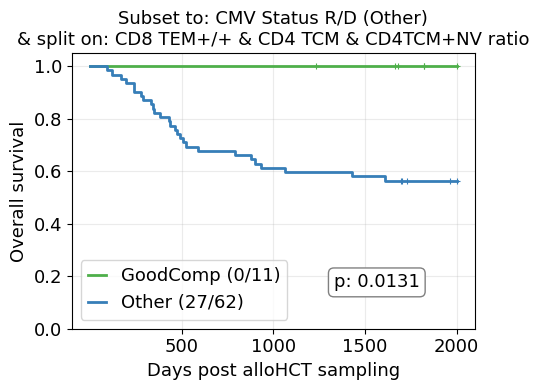

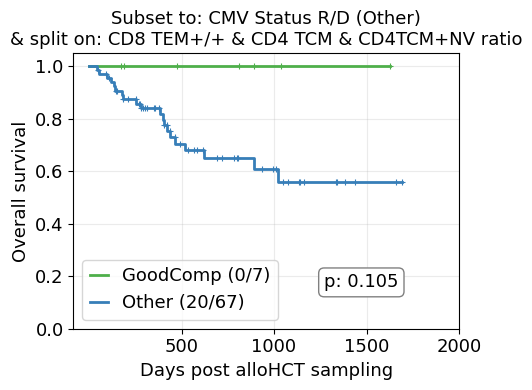

In [ ]:
for cohort in ['OC', 'VC']:
    if clinical_variable_KM == 'OS':
        plot_type = 'survival'
    elif clinical_variable_KM == 'RFS':
        plot_type = 'cumulative'
    # 'survival' / 'cumulative'
    width = 5
    height = 4
    # cohort = 'OC'

    if cohort == 'OC':
        df = d35_input_full_copy_C1.copy()
    elif cohort == 'VC':
        df = d35_input_full_copy_C2.copy()

    use_custom_pallette = True
    # custom_pallette = ['#b30059', '#9ec1e6', '#32CD32','#FFA500', '#FFD700', '#FFB8FF']
    # custom_pallette = ["#E06666", "#6FA8DC"]

    CLUSTER_COL = 'SplitVar'
    # specify the output directory for KM plots:
    base_dir_km_plots = ''
    save_path = f'{base_dir_km_plots}{path_renamer[selected_clin_var_col]}_{path_renamer[selected_score_col]}_{cohort}_OS.pdf'

    fig, ax = plt.subplots(figsize = (width, height)) 

    df = df.rename(columns={
        OUTCOME_COLS[clinical_variable_KM]["event"]: "event",
        OUTCOME_COLS[clinical_variable_KM]["time"]: "time"
    })

    custom_pallette = ["#4eaf4a", "#377eb8"]
    if cohort == 'OC':
        dict_main = renaming_dict_OC
    else:
        dict_main = renaming_dict_VC
    label_for_good_KM_test = dict_main[label_for_good]
    label_for_bad_KM_test = dict_main[label_for_bad]  
    groups = [label_for_good_KM_test, label_for_bad_KM_test]
    color_map = dict(zip(groups, ["#4eaf4a", "#377eb8"]))

    # fit + plot; collect km objects for the risk table
    kmfs = []
    for g in groups:
        mask = (df[CLUSTER_COL] == g)
        km = KaplanMeierFitter()
        km.fit(df.loc[mask, "time"],
                event_observed=df.loc[mask, "event"],
            #    label=f"{g}\n(# pat: {int(mask.sum())})")
            label=f"{g}")
        if plot_type == 'survival':
            km.plot_survival_function(
                ax=ax,
                ci_show=False,                 # no shaded CI band (like your target)
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),  # small censor ticks
                color=color_map[g],
                linewidth=2
            )
        elif plot_type == 'cumulative':
            km.plot_cumulative_density(
                ax=ax,
                ci_show=False,
                show_censors=True,
                censor_styles=dict(ms=4, mew=0.8),
                color=color_map[g],
                linewidth=2
            )
        kmfs.append(km)
    ax.set_ylim(0, 1.05)


    ax.grid(alpha=0.25)
    fontsize_fixed = 13
    # elif len(groups) > 2:
    # print('using the multivariate logrank test')

    results = logrank_test(
        df.loc[df[CLUSTER_COL] == label_for_good_KM_test, "time"],
        df.loc[df[CLUSTER_COL] == label_for_bad_KM_test, "time"],
        event_observed_A=df.loc[df[CLUSTER_COL] == label_for_good_KM_test, "event"],
        event_observed_B=df.loc[df[CLUSTER_COL] == label_for_bad_KM_test, "event"],
    )

    # results = multivariate_logrank_test(
    #     event_durations=df["time"],
    #     groups=df[CLUSTER_COL],
    #     event_observed=df["event"]
    # )
    if clinical_variable_KM == 'OS':
        ax.text(0.65, 0.15, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))
    elif clinical_variable_KM == 'RFS':
        ax.text(0.05, 0.85, f"p: {results.p_value:.3g}",
                transform=ax.transAxes, fontsize=fontsize_fixed,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha = 1))

    ax.set_title(f'Subset to: {title_renamer[selected_clin_var_col]}\n& split on: {title_renamer[selected_score_col]}', fontsize = fontsize_fixed)
    
    if clinical_variable_KM == 'RFS':
        ax.set_ylabel('Cumulative incidence\nof relapse', fontsize = fontsize_fixed)
    elif clinical_variable_KM == 'OS':
        ax.set_ylabel('Overall survival', fontsize = fontsize_fixed)
    ax.set_xlabel('Days post alloHCT sampling', fontsize = fontsize_fixed)
    ax.set_xticks([500, 1000, 1500, 2000])

    ax.tick_params(axis="y", labelsize = fontsize_fixed)
    ax.tick_params(axis="x", labelsize = fontsize_fixed)

    ax.legend(fontsize = fontsize_fixed,
              handlelength=0.7)
    if clinical_variable_KM == 'RFS':
        ax.legend(loc='upper right',
                  fontsize = fontsize_fixed,
                  handlelength=1)
    elif clinical_variable_KM == 'OS':
        ax.legend(loc='lower left',
                  fontsize = fontsize_fixed,
                  handlelength=1)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches = 'tight', transparent=True)
    plt.show()